# 01. epitope potential（薬剤誘導 glyco-epitope potential）

薬剤誘導トランスクリプトームから **各 glyco-epitope の増減 potential** を推定する。

**ロジック**（`docs/epitope_potential_design.md`）:
- エピトープの生合成酵素を GlycoEnzOnto 経路で **反応ステップ**に分割（`RAW.GLYCOEPITOPE.EPITOPE_STEP_GENE`）
- `step活性 A_s = max_{g∈step} z`（ステップ内 isoenzyme = OR）、`potential = min_s A_s`（ステップ間 = 律速 AND）
- **コントラスト**：明示的 DMSO 対照が無いため、遺伝子ごとに across-compound 平均を引いて中心化（＝平均的な薬よりどれだけ強く動かすか）

**データ**: `RAW.LINCS.GLYCO_GENES_WIDE`（cell=HEPG2）／出典 GlycoEnzOnto は CC-BY-4.0（Groth et al. 2022）、ロジックは GlycoMaple（Huang et al. 2021）。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector as sc

SF = dict(account='DUETMBM-LL33279', user='KOREEDA', role='ACCOUNTADMIN',
          warehouse='BIOINFORMATICS_XS', authenticator='SNOWFLAKE_JWT',
          private_key_file=os.path.expanduser('~/.ssh/snowflake_rsa_key.pem'))
CELL = 'HEPG2'
con = sc.connect(database='RAW', schema='GLYCOEPITOPE', **SF)
cur = con.cursor()
print('connected')

connected


## 1. ステップ対応表と glycogene 発現を取得

In [2]:
# epitope -> step -> gene
steps = cur.execute(
    'SELECT EPITOPE_ID, EPITOPE_NAME, STEP_ID, HGNC_SYMBOL FROM RAW.GLYCOEPITOPE.EPITOPE_STEP_GENE'
).fetch_pandas_all()

# GLYCO_GENES_WIDE に列がある遺伝子のみ使用
cols = set(r[0] for r in cur.execute(
    "SELECT COLUMN_NAME FROM RAW.INFORMATION_SCHEMA.COLUMNS "
    "WHERE TABLE_SCHEMA='LINCS' AND TABLE_NAME='GLYCO_GENES_WIDE'").fetchall())
genes = sorted(set(steps['HGNC_SYMBOL']) & cols)
missing = sorted(set(steps['HGNC_SYMBOL']) - cols)
print(f'使用遺伝子 {len(genes)} / 欠損 {missing}')

使用遺伝子 53 / 欠損 ['FUT5']


In [3]:
# 発現取得（メタ列は小文字クォート）→ 化合物平均
sel = ', '.join(['"pertname"'] + [f'"{g}"' for g in genes])
expr = cur.execute(
    f'SELECT {sel} FROM RAW.LINCS.GLYCO_GENES_WIDE WHERE "cell"=%s', (CELL,)).fetch_pandas_all()
expr.columns = ['pertname'] + genes
for g in genes:
    expr[g] = pd.to_numeric(expr[g], errors='coerce')
cmean = expr.groupby('pertname')[genes].mean()
print(f'化合物 {cmean.shape[0]} × 遺伝子 {cmean.shape[1]}（{CELL}）')
cmean.head(3)

化合物 4704 × 遺伝子 53（HEPG2）


,A4GALT,B3GALT4,B3GALT5,B3GAT1,B3GAT2,B3GLCT,B4GALNT1,B4GALT1,B4GALT2,B4GALT3,...,ST3GAL4,ST3GAL5,ST6GAL1,ST6GALNAC1,ST6GALNAC5,ST6GALNAC6,ST8SIA1,ST8SIA2,ST8SIA4,ST8SIA5
pertname,,,,,,,,,,,,,,,,,,,,,
1-HYDROXYANTHRAQUINONE,0.002950,0.000581,-0.003412,-0.003392,0.001576,-0.003494,-0.003228,0.001992,0.002313,0.003294,...,0.003305,-0.008418,0.005272,0.007178,0.002846,-0.002780,-0.000915,-0.003268,-0.002605,0.000026
1-NITRONAPHTHALENE,0.000503,-0.002766,-0.000975,-0.000025,-0.001757,0.000154,0.003425,-0.001323,-0.000697,-0.001526,...,-0.001049,0.005800,-0.005848,0.004051,-0.000851,-0.001884,-0.001935,0.001722,-0.001211,-0.000801
1-NITROSOAZOCANE,0.000540,0.003692,-0.003391,0.000086,0.000786,0.001729,0.001647,-0.000434,0.000446,-0.002003,...,-0.004222,0.002909,-0.002001,0.000389,-0.001034,0.003054,0.001066,-0.001092,-0.000393,-0.000030


## 2. potential 計算（step内max × step間min）＋ コントラスト

In [4]:
ep_steps = (steps[steps.HGNC_SYMBOL.isin(genes)]
            .groupby(['EPITOPE_ID', 'EPITOPE_NAME', 'STEP_ID'])['HGNC_SYMBOL']
            .apply(list).reset_index())

def potential_matrix(expr_by_compound):
    """化合物×遺伝子 → 化合物×エピトープ（step内max, step間min）"""
    out = {}
    for (epid, epname), grp in ep_steps.groupby(['EPITOPE_ID', 'EPITOPE_NAME']):
        step_max = [expr_by_compound[r['HGNC_SYMBOL']].max(axis=1) for _, r in grp.iterrows()]
        out[f'{epname}'] = pd.concat(step_max, axis=1).min(axis=1)
    return pd.DataFrame(out)

raw = potential_matrix(cmean)                       # 素
centered = cmean - cmean.mean(axis=0)               # 遺伝子を across-compound 中心化
contrast = potential_matrix(centered)              # コントラスト
zpot = (contrast - contrast.mean(axis=0)) / contrast.std(axis=0)  # 化合物間 z
print('shape:', contrast.shape, '（化合物 × エピトープ）')

shape: (4704, 49) （化合物 × エピトープ）


In [5]:
# 分離度: 素 vs コントラスト（0中心に広がるか）
print(f'素potential   : mean={raw.stack().mean():+.4f}  std={raw.stack().std():.4f}  '
      f'range[{raw.min().min():.3f},{raw.max().max():.3f}]')
print(f'コントラスト  : mean={contrast.stack().mean():+.4f}  std={contrast.stack().std():.4f}  '
      f'range[{contrast.min().min():.3f},{contrast.max().max():.3f}]')

素potential   : mean=+0.0008  std=0.0065  range[-0.038,0.039]
コントラスト  : mean=+0.0009  std=0.0065  range[-0.039,0.039]


## 3. 代表エピトープの 上げる薬 / 下げる薬

In [6]:
def top_drugs(epname, n=5):
    s = contrast[epname].dropna().sort_values(ascending=False)
    up = pd.DataFrame({'potential': s.head(n), 'z': zpot[epname][s.head(n).index]})
    dn = pd.DataFrame({'potential': s.tail(n), 'z': zpot[epname][s.tail(n).index]})
    return up, dn

for ep in ['Sialyl Lewis x', 'HNK-1', 'Lewis y']:
    if ep in contrast.columns:
        up, dn = top_drugs(ep)
        print(f'\n=== {ep} ===')
        print('▲ 増やす薬 top5'); print(up.round(3).to_string())
        print('▼ 減らす薬 bottom5'); print(dn.round(3).to_string())


=== Sialyl Lewis x ===
▲ 増やす薬 top5
               potential      z
pertname                       
talniflumate       0.019  4.560
doconexent         0.017  3.948
BRD-K24426149      0.016  3.616
ZM-323881          0.015  3.579
LY-364947          0.015  3.486
▼ 減らす薬 bottom5
               potential      z
pertname                       
BRD-K31828306     -0.012 -3.508
LY-456236         -0.013 -3.857
calcifediol       -0.013 -3.886
carprofen         -0.013 -3.914
phentolamine      -0.016 -4.469

=== HNK-1 ===
▲ 増やす薬 top5
                potential      z
pertname                        
naftifine           0.029  4.820
nicardipine         0.028  4.580
capsaicin           0.027  4.287
tyrphostin-B44      0.025  4.061
BRD-K30434763       0.025  3.922
▼ 減らす薬 bottom5
               potential      z
pertname                       
BRD-K67470788     -0.008 -2.465
CCCP              -0.008 -2.473
BRD-A18411371     -0.008 -2.488
BRD-K91913968     -0.008 -2.590
GBR-13069         -0.008 -2.632

===

## 4. ヒートマップ（薬剤 × エピトープ）

変動の大きいエピトープ上位と、|z|の大きい薬剤上位を抜き出して俯瞰。

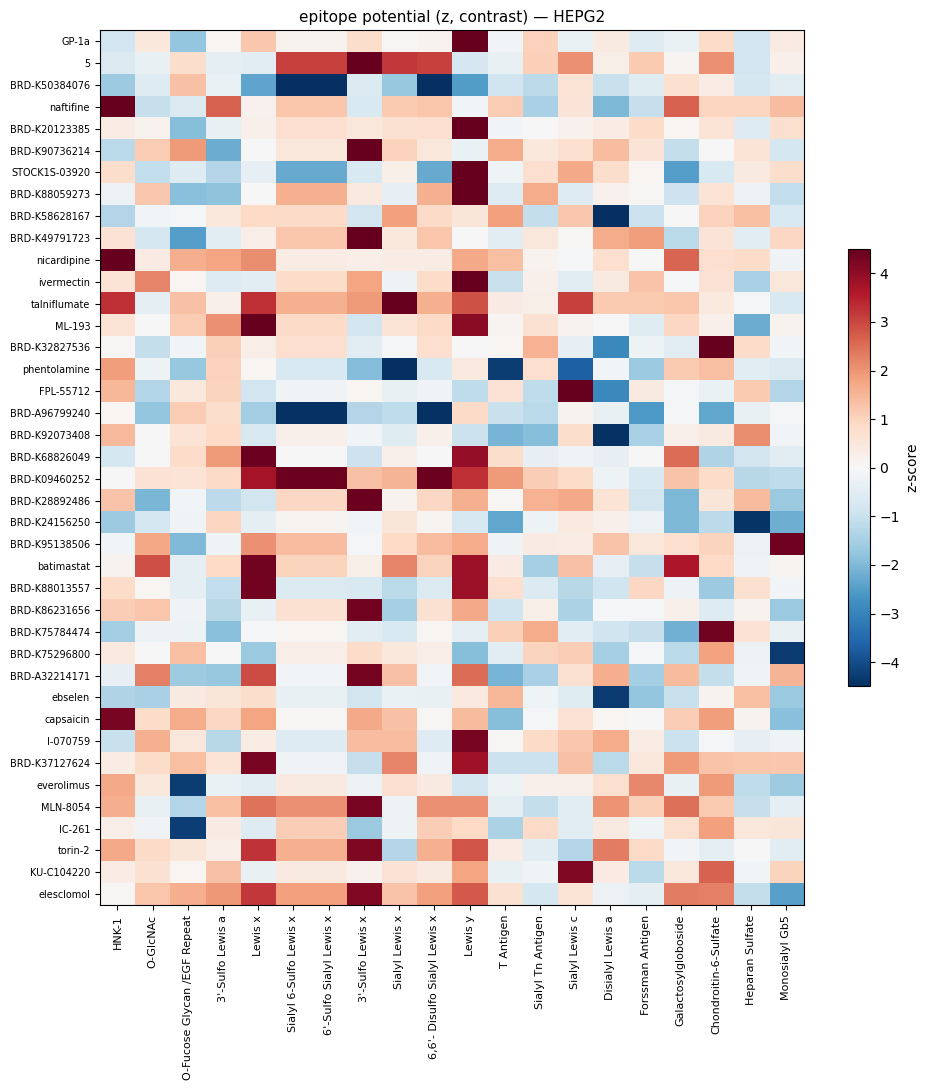

saved results/figures/epitope_potential_hepg2_heatmap.png


In [7]:
# 変動大きいエピトープ上位20、|z|大きい薬剤上位40
top_ep = zpot.std(axis=0).sort_values(ascending=False).head(20).index
top_drug = zpot[top_ep].abs().max(axis=1).sort_values(ascending=False).head(40).index
M = zpot.loc[top_drug, top_ep]

fig, ax = plt.subplots(figsize=(10, 11))
vmax = np.nanpercentile(np.abs(M.values), 98)
im = ax.imshow(M.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(top_ep))); ax.set_xticklabels(top_ep, rotation=90, fontsize=8)
ax.set_yticks(range(len(top_drug))); ax.set_yticklabels(top_drug, fontsize=7)
ax.set_title(f'epitope potential (z, contrast) — {CELL}', fontsize=11)
cb = fig.colorbar(im, ax=ax, shrink=0.5); cb.set_label('z-score')
plt.tight_layout()
os.makedirs('../../results/figures', exist_ok=True)
fig.savefig('../../results/figures/epitope_potential_hepg2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved results/figures/epitope_potential_hepg2_heatmap.png')

## 5. 出力保存

In [8]:
os.makedirs('../../results/tables', exist_ok=True)
contrast.to_csv('../../results/tables/epitope_potential_hepg2_contrast.csv')
zpot.to_csv('../../results/tables/epitope_potential_hepg2_z.csv')
print('saved contrast / z tables')
con.close()

saved contrast / z tables
